# this contains functional screen deseq2 analysis, MA plots and the validating non-validating definition

figures 2, S3

### load data

In [ ]:
import pandas as pd
import json
toolbox_path = "" 

ref_df_path = toolbox_path + "tcr_refs_df.csv"
ref_df = pd.read_csv(ref_df_path)
fasta_path = toolbox_path + "stapler_tcr_assembly_nanopore.fa"
fasta_data = {}
with open(fasta_path, "r") as fasta_in:
    for entry in fasta_in:
        if entry.startswith(">"):
            entry = entry[1:].strip('\n')
            name_entry = entry
            fasta_data[name_entry] = ""
        else:
            fasta_data[name_entry] += entry.strip()

print(len(fasta_data), 'fasta_data')
subset_data = list(fasta_data.keys())

print(len(ref_df) , 'ref_df before')
ref_df_subset = ref_df[ref_df['name'].isin(subset_data)].reset_index(drop=True).copy()
print(len(ref_df_subset) , 'ref_df after')


3693 fasta_data
7680 ref_df before
3693 ref_df after


### set parameters

In [ ]:
from utils import set_mpl_params 
import matplotlib as mpl
import matplotlib.font_manager as fm 

out_path_dropbox = ''
SAVE_DROPBOX = True
fm.fontManager.addfont("/Library/Fonts/Arial Unicode.ttf")
mpl, mylines = set_mpl_params(mpl)
figsize = (5.1/2.54, 4/2.54)
dotsize = 5
fontsize_axes = 7

background_alpha = 0.45
color_alpha = 0.6


In [ ]:
import os
def glob_all_nested_files(path, pattern):
    return [os.path.join(root, file)
            for root, dirs, files in os.walk(path)
            for file in files if pattern in file]

baseline_files = glob_all_nested_files(
    '/seq_data', 'baseline')
baseline_files = [f for f in baseline_files if f.endswith('.csv')]

In [ ]:
baseline_dict_orig = {
    'baseline_glc_ylq_b': '/seq_data/3_stapler_vdjdb_ylq_glc_screen_baseline/outs_b/concatenated_barcode02_baseline_b/concatenated_barcode02_baseline_b_filtered_umi_count.csv',
    'baseline_ltd_atd_ttd_2': '/seq_data/10_stapler_vdjdb_baselines-GIL-LTD_GILpositivesABC-repeat/outs/concatenated_barcode16_baseline_ltd/concatenated_barcode16_baseline_ltd_filtered_umi_count.csv',
    'baseline_gil_nlv_2': '/seq_data/10_stapler_vdjdb_baselines-GIL-LTD_GILpositivesABC-repeat/outs/concatenated_barcode20_baseline_gil/concatenated_barcode20_baseline_gil_filtered_umi_count.csv',
    'baseline_tetramer': '/seq_data/11_tetramer_sort_june-2025/outs/concatenated_barcode12_baseline_tetramer/concatenated_barcode12_baseline_tetramer_filtered_umi_count.csv'
}

baseline_dict = {
    'baseline_a': '/seq_data/3_stapler_vdjdb_ylq_glc_screen_baseline/outs_b/concatenated_barcode02_baseline_b/concatenated_barcode02_baseline_b_filtered_umi_count.csv',
    'baseline_b': '/seq_data/11_tetramer_sort_june-2025/outs/concatenated_barcode12_baseline_tetramer/concatenated_barcode12_baseline_tetramer_filtered_umi_count.csv',
    'baseline_c': '/seq_data/10_stapler_vdjdb_baselines-GIL-LTD_GILpositivesABC-repeat/outs/concatenated_barcode20_baseline_gil/concatenated_barcode20_baseline_gil_filtered_umi_count.csv',
}

### load arrayed validation data

In [ ]:
pilot_data_glc = pd.read_csv(
    "glc_pilot_result_screen_translation.csv",
    sep=";"
)
pilot_data_ylq = pd.read_csv(
    "ylq_pilot_result_screen_translation.csv",
    sep=";"
)

In [ ]:
for name, baseline in baseline_dict_orig.items():
    df1 = pd.read_csv(baseline)
    for name2, baseline2 in baseline_dict_orig.items(): 
        if name == name2:
            continue
        df2 = pd.read_csv(baseline2)
        merged_df = pd.merge(df1, df2, on='TCR', suffixes=('_1', '_2'))

### set up comparisons

In [ ]:
run_dict = [
    {
        'outs_path' :'/seq_data/3_stapler_vdjdb_ylq_glc_screen_baseline/outs_concatenated',
        'epitope1' : 'GLCTLVAML',
        'epitope2' : 'YLQPRTFLL',
    },
    {
        'outs_path' : '/seq_data/5_stapler_vdjdb_gil_nlv_screen/outs',
        'epitope1' : 'GILGFVFTL',
        'epitope2' : 'NLVPMVATV',
    },
    {   'outs_path' : '/seq_data/6_stapler_vdjdb_cin_llw_screen/outs',
        'epitope1' : 'CINGVCWTV',
        'epitope2' : 'LLWNGPMAV',
    },
        {
        'outs_path' : '/seq_data/7_stapler_vdjdb_ltd_atd_ttd_screen/outs_ttd_ltd',
        'epitope1' : 'TTDPSFLGRY',
        'epitope2' : 'LTDEMIAQY',

    },
        {
        'outs_path' : '/seq_data/11_tetramer_sort_june-2025/outs',
        'epitope1' : 'GLCTLVAML',
        'epitope2' : 'YLQPRTFLL',
        'baseline' : '/seq_data/11_tetramer_sort_june-2025/outs/concatenated_barcode12_baseline_tetramer/concatenated_barcode12_baseline_tetramer_filtered_umi_count.csv',
    }
]

### colors

In [ ]:
import pandas as pd
colors_dict = {}

color_name_dict = {
    'lightgrey': 'other annotated',
    # 'crimson': 'GILGFVFTL annotated',      # red
    'plum': 'GILGFVFTL annotated',      # red
    'cornflowerblue': 'YLQPRTFLL annotated', # blue
    'forestgreen': 'TTDPSFLGRY annotated',   # green
    'darkorange': 'NLVPMVATV annotated',     # orange
    'mediumorchid': 'SPRWYFYYL annotated',   # purple
    'darkturquoise': 'CINGVCWTV annotated',  # turquoise
    'gold': 'LLWNGPMAV annotated',           # yellow
    'indianred': 'GLCTLVAML annotated',        # deep red
    'darkviolet': 'LTDEMIAQY annotated',     # violet
    'teal': 'ATDALMTGF annotated',           # teal
    'magenta': 'hla-b0702',
    'darkgrey': 'control',
    'TBD': 'aspecific control',
    'brown': 'not_this_epi',  # brown
    'lime': 'sig_in_tetra',
    'purple': 'selected_sig_in_tetra',
    'darkgreen': 'ylq_wrong_side_preprint_version',
    'black': 'ambiguous',
    'darkgray': 'negative'

}
color_list = color_name_dict.keys()
color_list = list(color_list)


In [ ]:
import matplotlib.colors as mcolors

with open('name_color_dict_rebuttal.json', 'r') as f:
    name_color_dict = json.load(f)
    
name_color_dict = {k: v for k, v in name_color_dict.items() if v != 'TBD' and v != 'other'}
    
def darken_color(color_name, factor=0.7):
    rgb = mcolors.to_rgb(color_name)
    darker_rgb = tuple(max(0, c * factor) for c in rgb)
    return mcolors.to_hex(darker_rgb)


name_color_dict_darker = {k: darken_color(v, 0.55) for k, v in name_color_dict.items()}


In [ ]:
### baseline
runs_df_baseline = pd.DataFrame()

for name, filepath in baseline_dict.items():  
        df_orig = pd.read_csv(os.path.join(filepath),index_col=0)
        df = df_orig

        df.rename(columns={'Count': name}, inplace=True)
        df = df.T
        df.columns = df.loc['TCR']
        df = df.drop('log_transformed_count')
        df = df.drop('TCR')

        runs_df_baseline = pd.concat([runs_df_baseline, df])
runs_df_baseline = runs_df_baseline.fillna(0)

In [ ]:
GIL_path = '/seq_data/10_stapler_vdjdb_baselines-GIL-LTD_GILpositivesABC-repeat/outs/outs_gil_repeat_copy'   

gil_df = pd.DataFrame()
for dirpath, dirnames, filenames in os.walk(GIL_path):
        for filename in filenames:  
            if filename.endswith('.csv') and 'concatenated' in filename:
                if 'neg' in filename:
                    continue
                
                df_orig = pd.read_csv(os.path.join(dirpath, filename),index_col=0)
                df = df_orig
                epitope = os.path.splitext(filename)[0].split('_')[2]
                repeat = os.path.splitext(filename)[0].split('_')[5]
                name = epitope + '_' + repeat

                df.rename(columns={'Count': name}, inplace=True)
                df = df.T
                df.columns = df.loc['TCR']
                df = df.drop('log_transformed_count')
                df = df.drop('TCR')
                
                gil_df = pd.concat([gil_df, df])
gil_df = gil_df.fillna(0)

In [ ]:
import os
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

run_df_all_dict = {}
for run in run_dict:
    outs_path = run['outs_path']
    epitope1 = run['epitope1']
    epitope2 = run['epitope2']
    epitope1_short = epitope1[:3].lower()
    epitope2_short = epitope2[:3].lower()
    print(f"Processing run: epitopes {epitope1} and {epitope2}")

    runs_df = pd.DataFrame()
    for dirpath, dirnames, filenames in os.walk(outs_path):
        for filename in filenames:  
            if filename.endswith('.csv') and 'concatenated' in filename:
                if 'neg' in filename:
                    print('skipping', filename)
                    continue
                
                print(filename)
                epitope = os.path.splitext(filename)[0].split('_')[2]
                repeat = os.path.splitext(filename)[0].split('_')[5]
                if 'gil' in epitope.lower():
                    continue
                if 'baseline' in filename:
                    continue
                if 'hla-b0702' in filename:
                    continue

                df_orig = pd.read_csv(os.path.join(dirpath, filename),index_col=0)
                df = df_orig
                print(epitope, repeat, (len(df)))
                if 'tetramer' in filename:
                    # For tetramer files, use the full epitope name
                    name = epitope + '-tetramer_' + repeat
                else:
                    name = epitope + '_' + repeat

                df.rename(columns={'Count': name}, inplace=True)
                print(df[name].min(), df[name].max(), 'min max of', name)
                df = df.T
                df.columns = df.loc['TCR']
                df = df.drop('log_transformed_count')
                df = df.drop('TCR')
                
                run_df_all_dict[name] = df
                print()


for name, df in gil_df.iterrows():
    df = df.to_frame().T
    df.index = [name]
    run_df_all_dict[name] = df

Processing run: epitopes GLCTLVAML and YLQPRTFLL
concatenated_barcode04_ylq_cd69_pos_a_filtered_umi_count.csv
ylq a 3510
3 2135 min max of ylq_a

concatenated_barcode08_glc_cd69_pos_b_filtered_umi_count.csv
glc b 3534
3 3033 min max of glc_b

concatenated_barcode09_glc_cd69_pos_c_filtered_umi_count.csv
glc c 3506
3 1666 min max of glc_c

concatenated_barcode05_ylq_cd69_pos_b_filtered_umi_count.csv
ylq b 3540
3 3152 min max of ylq_b

concatenated_barcode07_glc_cd69_pos_a_filtered_umi_count.csv
glc a 3503
3 1415 min max of glc_a

concatenated_barcode06_ylq_cd69_pos_c_filtered_umi_count.csv
ylq c 3497
3 1607 min max of ylq_c

Processing run: epitopes GILGFVFTL and NLVPMVATV
concatenated_barcode14_gil_cd69_pos_b_filtered_umi_count.csv
concatenated_barcode15_gil_cd69_pos_c_filtered_umi_count.csv
skipping concatenated_barcode19_nlv_cd69_neg_b_filtered_umi_count.csv
concatenated_barcode17_nlv_cd69_pos_b_filtered_umi_count.csv
nlv b 3155
2 774 min max of nlv_b

concatenated_barcode18_nlv_cd69_

In [ ]:
condition_list = list(set([name.split('_')[0] for name in run_df_all_dict.keys()]))
condition_list_no_tetramer = [name for name in condition_list if 'tetramer' not in name]
condition_list_no_tetramer_ylq_glc = condition_list_no_tetramer + ['GLCTLVAML_YLQPRTFLL']

In [124]:
all_epitopes = ['GILGFVFTL', 'YLQPRTFLL', 'TTDPSFLGRY', 'NLVPMVATV', 'SPRWYFYYL',
       'CINGVCWTV', 'LLWNGPMAV', 'GLCTLVAML', 'LTDEMIAQY', 'ATDALMTGF']
short_to_long_epi = {
     'cin': 'CINGVCWTV',
    'gil': 'GILGFVFTL',
    'glc': 'GLCTLVAML',
    'llw': 'LLWNGPMAV',
    'ltd': 'LTDEMIAQY',
    'nlv': 'NLVPMVATV',
    'ttd': 'TTDPSFLGRY',
    'ylq': 'YLQPRTFLL',
    'spr': 'SPRWYFYYL',
    'glc-tetramer': 'GLCTLVAML',
    'ylq-tetramer': 'YLQPRTFLL',
    'hla-b0702': 'hla-b0702_mock',
}

### for plotting of subsets inside the MA plot we load the validating non-validating data (defined later)

In [ ]:
# read
import json
stats_path = "experiment_set_stats_all-v-1.json"
with open(stats_path, 'r') as f:
    stats_data_allv1 = json.load(f)


In [ ]:
sig_hits_dict_single_comp = {}
sig_hits_dict_single_comp_dfs = {}
threshold_dict = {}
set_stats = {}

new_df = pd.DataFrame()
condition_keys = [key for key in run_df_all_dict.keys() if key.split('_')[0] in condition_list_no_tetramer]
new_df = pd.concat([run_df_all_dict[key] for key in condition_keys])

counts_df = new_df.copy() 
counts_df = counts_df.fillna(0)
counts_df = counts_df.sort_index()

### use counts_df tcrs detected in screens to make the final validating non-validating prediction df


In [ ]:
all_tcrs = counts_df.columns

print(len(ref_df_subset), 'ref_df_subset before filtering with all_tcrs')
ref_df_subset_screened = ref_df_subset[ref_df_subset['name'].isin(all_tcrs)].reset_index(drop=True).copy()
print(len(ref_df_subset_screened), 'ref_df_subset after filtering with all_tcrs')
# # ref_df_subset_screened.to_csv('saved_dfs/ref_df_subset_screened.csv', index=False)

3693 ref_df_subset before filtering with all_tcrs
3577 ref_df_subset after filtering with all_tcrs


In [129]:
print(counts_df.sum(axis=1))

cin_a    150772
cin_b    152867
cin_c    138093
gil_a    155073
gil_b    227553
gil_c    252392
glc_a    239115
glc_b    449838
glc_c    259941
llw_a    136588
llw_b    133456
llw_c    126375
ltd_a    177440
ltd_b    164125
ltd_c    284024
nlv_a    220288
nlv_b     63773
nlv_c    211602
ttd_a    211402
ttd_b    137891
ttd_c    270447
ylq_a    303993
ylq_b    507431
ylq_c    258526
dtype: int64


In [133]:
run_sets = {}
for i, run in enumerate(run_dict):
    epi_1 = run['epitope1']
    epi_2 = run['epitope2']

    if epi_1 not in run_sets.keys() and epi_1 != 'MOCK':
        run_sets[epi_1.lower()[0:3]] = i
    if epi_2 not in run_sets.keys() and epi_2 != 'MOCK':
        run_sets[epi_2.lower()[0:3]] = i

run_sets

{'glc': 4,
 'ylq': 4,
 'gil': 1,
 'nlv': 1,
 'cin': 2,
 'llw': 2,
 'ttd': 3,
 'ltd': 3}

In [134]:
stats_data_allv1['GILGFVFTL'].keys()

dict_keys(['intersection_ids', 'ambiguous_ids', 'pos_ids', 'neg_ids', 'all_ids', 'not_annotated_for_this_epitope_but_above_threshold', 'threshold_pos', 'threshold_neg'])

### we make all different plots in a single loop

In [135]:
all_plot_types = [
    # 'all-colored',
    'pos-neg-ambig',
    # 'pos-neg-only',
    # 'arrayed-pilot',
    # 'all-grey-nlv',
    # 'allele-collapsed',
    # 'tetramer_only_hits',
]

Processing plot type: pos-neg-ambig
Processing condition: glc
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.51 seconds.

Fitting dispersion trend curve...
... done in 0.06 seconds.

Fitting MAP dispersions...
... done in 0.53 seconds.

Fitting LFCs...
... done in 0.38 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Running Wald tests...


[0.65260725 0.66346238 0.57064904 0.40063087 0.54888853 0.61134493
 1.39805502 2.5908072  1.52272751 0.61403646 0.6070337  0.52945959
 0.93886212 0.8928313  1.55594283 1.11733844 0.33858376 1.09593328
 1.06590246 0.68764406 1.37348522 1.69616029 2.93391324 1.46862749]


... done in 0.20 seconds.



Log2 fold change & Wald test p-value: condition glc vs baseline
                          baseMean  log2FoldChange     lfcSE      stat  \
TCR                                                                      
2_18_B10_21_YPDKVFRSSV   41.148392        0.429958  0.493824  0.870672   
2_16_H5_88_GLCTLVAML      7.831341       -0.189899  1.244193  0.000000   
2_14_H15_182_LLWNGPMAV   52.603541       -0.332820  0.194045  0.000000   
2_15_A2_1_LLWNGPMAV     122.498117       -1.802019  1.122306  0.000000   
1_5_G2_73_YLQPRTFLL     101.537148       -1.291783  0.351517  0.000000   
...                            ...             ...       ...       ...   
2_11_B10_21_NLVPMVATV     0.114058       -1.520934  4.829001  0.000000   
2_11_G5_76_SPRWYFYYL      0.343199       -1.841451  4.820319  0.000000   
2_11_C16_123_SPRWYFYYL    0.597896       -2.674239  4.611171  0.000000   
1_7_B15_110_TTDPSFLGRY    1.481320       -4.046100  3.574724  0.000000   
1_7_D24_143_TTDPSFLGRY    0.117272       -1.5209

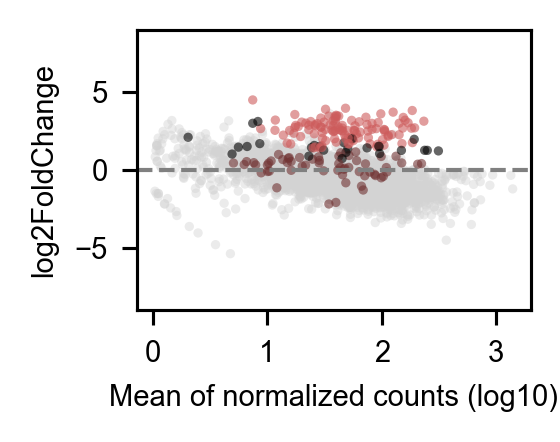

MEAN LFC of hits in pos side: 2.5925451376988393 => lfc_null for neg side: 1.711079790881234
######################
1.711079790881234
######################


Running Wald tests...
... done in 0.21 seconds.



Log2 fold change & Wald test p-value: condition glc vs baseline
                          baseMean  log2FoldChange     lfcSE       stat  \
TCR                                                                       
2_18_B10_21_YPDKVFRSSV   41.148392        0.429958  0.493824  -2.594289   
2_16_H5_88_GLCTLVAML      7.831341       -0.189899  1.244193  -1.527881   
2_14_H15_182_LLWNGPMAV   52.603541       -0.332820  0.194045 -10.533099   
2_15_A2_1_LLWNGPMAV     122.498117       -1.802019  1.122306  -3.130250   
1_5_G2_73_YLQPRTFLL     101.537148       -1.291783  0.351517  -8.542576   
...                            ...             ...       ...        ...   
2_11_B10_21_NLVPMVATV     0.114058       -1.520934  4.829001  -0.669293   
2_11_G5_76_SPRWYFYYL      0.343199       -1.841451  4.820319  -0.736991   
2_11_C16_123_SPRWYFYYL    0.597896       -2.674239  4.611171  -0.951021   
1_7_B15_110_TTDPSFLGRY    1.481320       -4.046100  3.574724  -1.610524   
1_7_D24_143_TTDPSFLGRY    0.117272  

Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.39 seconds.

Fitting dispersion trend curve...
... done in 0.06 seconds.

Fitting MAP dispersions...
... done in 0.39 seconds.

Fitting LFCs...
... done in 0.23 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Running Wald tests...
... done in 0.18 seconds.



[0.65260725 0.66346238 0.57064904 0.40063087 0.54888853 0.61134493
 1.39805502 2.5908072  1.52272751 0.61403646 0.6070337  0.52945959
 0.93886212 0.8928313  1.55594283 1.11733844 0.33858376 1.09593328
 1.06590246 0.68764406 1.37348522 1.69616029 2.93391324 1.46862749]
Log2 fold change & Wald test p-value: condition nlv vs baseline
                          baseMean  log2FoldChange     lfcSE      stat  \
TCR                                                                      
2_18_B10_21_YPDKVFRSSV   41.148392        0.154966  0.519957  0.298037   
2_16_H5_88_GLCTLVAML      7.831341       -1.882332  1.336305  0.000000   
2_14_H15_182_LLWNGPMAV   52.603541       -0.027960  0.229504  0.000000   
2_15_A2_1_LLWNGPMAV     122.498117       -1.835964  1.126980  0.000000   
1_5_G2_73_YLQPRTFLL     101.537148       -0.541280  0.420345  0.000000   
...                            ...             ...       ...       ...   
2_11_B10_21_NLVPMVATV     0.114058        2.421597  4.543776  0.532948   
2

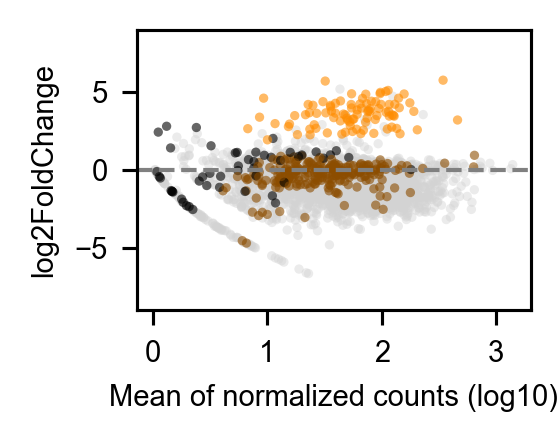

MEAN LFC of hits in pos side: 3.594861813592639 => lfc_null for neg side: 2.3726087969711416
######################
2.3726087969711416
######################


Running Wald tests...
... done in 0.32 seconds.



Log2 fold change & Wald test p-value: condition nlv vs baseline
                          baseMean  log2FoldChange     lfcSE       stat  \
TCR                                                                       
2_18_B10_21_YPDKVFRSSV   41.148392        0.154966  0.519957  -4.265052   
2_16_H5_88_GLCTLVAML      7.831341       -1.882332  1.336305  -3.184109   
2_14_H15_182_LLWNGPMAV   52.603541       -0.027960  0.229504 -10.459814   
2_15_A2_1_LLWNGPMAV     122.498117       -1.835964  1.126980  -3.734382   
1_5_G2_73_YLQPRTFLL     101.537148       -0.541280  0.420345  -6.932137   
...                            ...             ...       ...        ...   
2_11_B10_21_NLVPMVATV     0.114058        2.421597  4.543776   0.000000   
2_11_G5_76_SPRWYFYYL      0.343199       -0.423706  4.849859  -0.576576   
2_11_C16_123_SPRWYFYYL    0.597896       -1.307779  4.637857  -0.793554   
1_7_B15_110_TTDPSFLGRY    1.481320       -2.791395  3.637632  -1.419606   
1_7_D24_143_TTDPSFLGRY    0.117272  

Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.44 seconds.

Fitting dispersion trend curve...
... done in 0.06 seconds.

Fitting MAP dispersions...
... done in 0.42 seconds.

Fitting LFCs...
... done in 0.25 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Running Wald tests...


[0.65260725 0.66346238 0.57064904 0.40063087 0.54888853 0.61134493
 1.39805502 2.5908072  1.52272751 0.61403646 0.6070337  0.52945959
 0.93886212 0.8928313  1.55594283 1.11733844 0.33858376 1.09593328
 1.06590246 0.68764406 1.37348522 1.69616029 2.93391324 1.46862749]


... done in 0.20 seconds.



Log2 fold change & Wald test p-value: condition ylq vs baseline
                          baseMean  log2FoldChange     lfcSE      stat  \
TCR                                                                      
2_18_B10_21_YPDKVFRSSV   41.148392        0.850426  0.447527  1.900279   
2_16_H5_88_GLCTLVAML      7.831341       -0.664320  1.241571  0.000000   
2_14_H15_182_LLWNGPMAV   52.603541        0.209094  0.192568  1.085820   
2_15_A2_1_LLWNGPMAV     122.498117       -1.683700  1.125091  0.000000   
1_5_G2_73_YLQPRTFLL     101.537148        1.208864  0.305159  3.961419   
...                            ...             ...       ...       ...   
2_11_B10_21_NLVPMVATV     0.114058       -1.667151  4.830710  0.000000   
2_11_G5_76_SPRWYFYYL      0.343199       -1.978201  4.822261  0.000000   
2_11_C16_123_SPRWYFYYL    0.597896       -2.810801  4.609144  0.000000   
1_7_B15_110_TTDPSFLGRY    1.481320       -4.182093  3.569487  0.000000   
1_7_D24_143_TTDPSFLGRY    0.117272       -1.6671

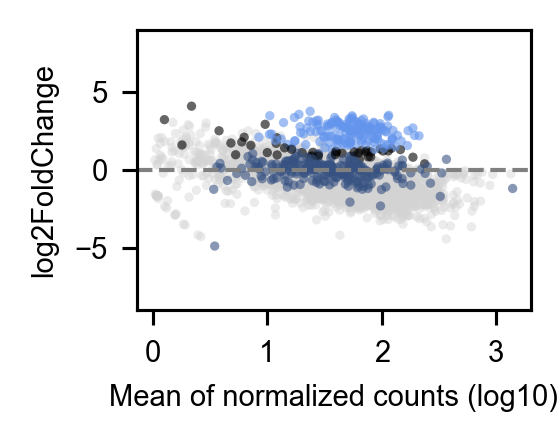

MEAN LFC of hits in pos side: 2.4493515517832765 => lfc_null for neg side: 1.6165720241769626
######################
1.6165720241769626
######################


Running Wald tests...
... done in 0.35 seconds.



Log2 fold change & Wald test p-value: condition ylq vs baseline
                          baseMean  log2FoldChange     lfcSE      stat  \
TCR                                                                      
2_18_B10_21_YPDKVFRSSV   41.148392        0.850426  0.447527 -1.711955   
2_16_H5_88_GLCTLVAML      7.831341       -0.664320  1.241571 -1.837102   
2_14_H15_182_LLWNGPMAV   52.603541        0.209094  0.192568 -7.309006   
2_15_A2_1_LLWNGPMAV     122.498117       -1.683700  1.125091 -2.933337   
1_5_G2_73_YLQPRTFLL     101.537148        1.208864  0.305159 -1.336051   
...                            ...             ...       ...       ...   
2_11_B10_21_NLVPMVATV     0.114058       -1.667151  4.830710 -0.679760   
2_11_G5_76_SPRWYFYYL      0.343199       -1.978201  4.822261 -0.745454   
2_11_C16_123_SPRWYFYYL    0.597896       -2.810801  4.609144 -0.960563   
1_7_B15_110_TTDPSFLGRY    1.481320       -4.182093  3.569487 -1.624509   
1_7_D24_143_TTDPSFLGRY    0.117272       -1.6671

Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.47 seconds.

Fitting dispersion trend curve...
... done in 0.06 seconds.

Fitting MAP dispersions...
... done in 0.51 seconds.

Fitting LFCs...
... done in 0.30 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Running Wald tests...


[0.65260725 0.66346238 0.57064904 0.40063087 0.54888853 0.61134493
 1.39805502 2.5908072  1.52272751 0.61403646 0.6070337  0.52945959
 0.93886212 0.8928313  1.55594283 1.11733844 0.33858376 1.09593328
 1.06590246 0.68764406 1.37348522 1.69616029 2.93391324 1.46862749]


... done in 0.26 seconds.



Log2 fold change & Wald test p-value: condition llw vs baseline
                          baseMean  log2FoldChange     lfcSE       stat  \
TCR                                                                       
2_18_B10_21_YPDKVFRSSV   41.148392       -0.837344  0.511252   0.000000   
2_16_H5_88_GLCTLVAML      7.831341       -1.108190  1.317885   0.000000   
2_14_H15_182_LLWNGPMAV   52.603541        0.075642  0.233226   0.324330   
2_15_A2_1_LLWNGPMAV     122.498117        4.475096  0.253416  17.659063   
1_5_G2_73_YLQPRTFLL     101.537148       -0.315731  0.426767   0.000000   
...                            ...             ...       ...        ...   
2_11_B10_21_NLVPMVATV     0.114058        0.302111  4.821008   0.062665   
2_11_G5_76_SPRWYFYYL      0.343199        3.873542  4.477877   0.865040   
2_11_C16_123_SPRWYFYYL    0.597896        3.679946  3.711700   0.991445   
1_7_B15_110_TTDPSFLGRY    1.481320       -2.432384  3.666283   0.000000   
1_7_D24_143_TTDPSFLGRY    0.117272  

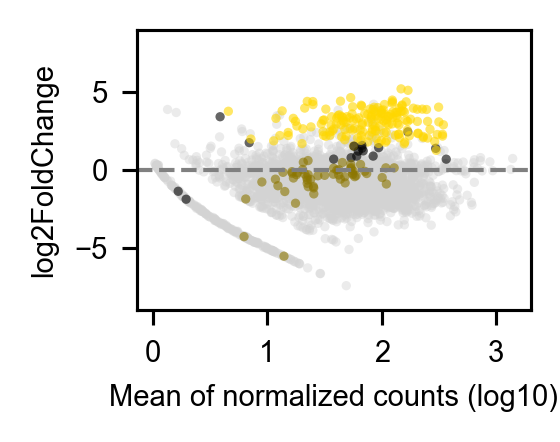

MEAN LFC of hits in pos side: 3.0541342894048586 => lfc_null for neg side: 2.0157286310072067
######################
2.0157286310072067
######################


Running Wald tests...
... done in 0.32 seconds.



Log2 fold change & Wald test p-value: condition llw vs baseline
                          baseMean  log2FoldChange     lfcSE      stat  \
TCR                                                                      
2_18_B10_21_YPDKVFRSSV   41.148392       -0.837344  0.511252 -5.580560   
2_16_H5_88_GLCTLVAML      7.831341       -1.108190  1.317885 -2.370403   
2_14_H15_182_LLWNGPMAV   52.603541        0.075642  0.233226 -8.318476   
2_15_A2_1_LLWNGPMAV     122.498117        4.475096  0.253416  0.000000   
1_5_G2_73_YLQPRTFLL     101.537148       -0.315731  0.426767 -5.463077   
...                            ...             ...       ...       ...   
2_11_B10_21_NLVPMVATV     0.114058        0.302111  4.821008 -0.355448   
2_11_G5_76_SPRWYFYYL      0.343199        3.873542  4.477877  0.000000   
2_11_C16_123_SPRWYFYYL    0.597896        3.679946  3.711700  0.000000   
1_7_B15_110_TTDPSFLGRY    1.481320       -2.432384  3.666283 -1.213249   
1_7_D24_143_TTDPSFLGRY    0.117272        0.3021

Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.53 seconds.

Fitting dispersion trend curve...
... done in 0.06 seconds.

Fitting MAP dispersions...
... done in 0.64 seconds.

Fitting LFCs...
... done in 0.28 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Running Wald tests...


[0.65260725 0.66346238 0.57064904 0.40063087 0.54888853 0.61134493
 1.39805502 2.5908072  1.52272751 0.61403646 0.6070337  0.52945959
 0.93886212 0.8928313  1.55594283 1.11733844 0.33858376 1.09593328
 1.06590246 0.68764406 1.37348522 1.69616029 2.93391324 1.46862749]


... done in 0.24 seconds.



Log2 fold change & Wald test p-value: condition ttd vs baseline
                          baseMean  log2FoldChange     lfcSE      stat  \
TCR                                                                      
2_18_B10_21_YPDKVFRSSV   41.148392        0.065894  0.513544  0.128312   
2_16_H5_88_GLCTLVAML      7.831341       -2.310709  1.302441  0.000000   
2_14_H15_182_LLWNGPMAV   52.603541        0.305021  0.203586  1.498244   
2_15_A2_1_LLWNGPMAV     122.498117       -1.931343  1.120799  0.000000   
1_5_G2_73_YLQPRTFLL     101.537148       -0.410379  0.418507  0.000000   
...                            ...             ...       ...       ...   
2_11_B10_21_NLVPMVATV     0.114058       -0.604500  4.830426  0.000000   
2_11_G5_76_SPRWYFYYL      0.343199       -0.931056  4.821574  0.000000   
2_11_C16_123_SPRWYFYYL    0.597896       -1.832172  4.598930  0.000000   
1_7_B15_110_TTDPSFLGRY    1.481320        4.409915  2.322582  1.898712   
1_7_D24_143_TTDPSFLGRY    0.117272        2.2079

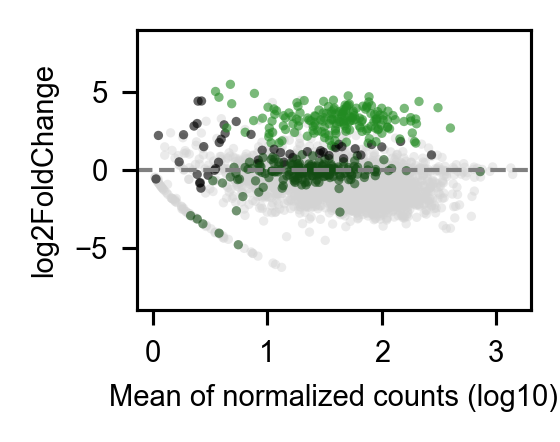

MEAN LFC of hits in pos side: 3.196954103401854 => lfc_null for neg side: 2.109989708245224
######################
2.109989708245224
######################


Running Wald tests...
... done in 0.29 seconds.



Log2 fold change & Wald test p-value: condition ttd vs baseline
                          baseMean  log2FoldChange     lfcSE      stat  \
TCR                                                                      
2_18_B10_21_YPDKVFRSSV   41.148392        0.065894  0.513544 -3.980374   
2_16_H5_88_GLCTLVAML      7.831341       -2.310709  1.302441 -3.394165   
2_14_H15_182_LLWNGPMAV   52.603541        0.305021  0.203586 -8.865891   
2_15_A2_1_LLWNGPMAV     122.498117       -1.931343  1.120799 -3.605759   
1_5_G2_73_YLQPRTFLL     101.537148       -0.410379  0.418507 -6.022280   
...                            ...             ...       ...       ...   
2_11_B10_21_NLVPMVATV     0.114058       -0.604500  4.830426 -0.561957   
2_11_G5_76_SPRWYFYYL      0.343199       -0.931056  4.821574 -0.630716   
2_11_C16_123_SPRWYFYYL    0.597896       -1.832172  4.598930 -0.857191   
1_7_B15_110_TTDPSFLGRY    1.481320        4.409915  2.322582  0.000000   
1_7_D24_143_TTDPSFLGRY    0.117272        2.2079

Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.50 seconds.

Fitting dispersion trend curve...
... done in 0.06 seconds.

Fitting MAP dispersions...
... done in 0.55 seconds.

Fitting LFCs...
... done in 0.32 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Running Wald tests...


[0.65260725 0.66346238 0.57064904 0.40063087 0.54888853 0.61134493
 1.39805502 2.5908072  1.52272751 0.61403646 0.6070337  0.52945959
 0.93886212 0.8928313  1.55594283 1.11733844 0.33858376 1.09593328
 1.06590246 0.68764406 1.37348522 1.69616029 2.93391324 1.46862749]


... done in 0.30 seconds.



Log2 fold change & Wald test p-value: condition ltd vs baseline
                          baseMean  log2FoldChange     lfcSE      stat  \
TCR                                                                      
2_18_B10_21_YPDKVFRSSV   41.148392        0.050732  0.513065  0.098880   
2_16_H5_88_GLCTLVAML      7.831341       -1.120489  1.263481  0.000000   
2_14_H15_182_LLWNGPMAV   52.603541       -0.120291  0.216470  0.000000   
2_15_A2_1_LLWNGPMAV     122.498117       -2.245294  1.111764  0.000000   
1_5_G2_73_YLQPRTFLL     101.537148       -0.481558  0.415582  0.000000   
...                            ...             ...       ...       ...   
2_11_B10_21_NLVPMVATV     0.114058       -0.748580  4.827947  0.000000   
2_11_G5_76_SPRWYFYYL      0.343199       -1.071520  4.819189  0.000000   
2_11_C16_123_SPRWYFYYL    0.597896       -1.972084  4.623856  0.000000   
1_7_B15_110_TTDPSFLGRY    1.481320        0.715011  3.208799  0.222828   
1_7_D24_143_TTDPSFLGRY    0.117272       -0.7485

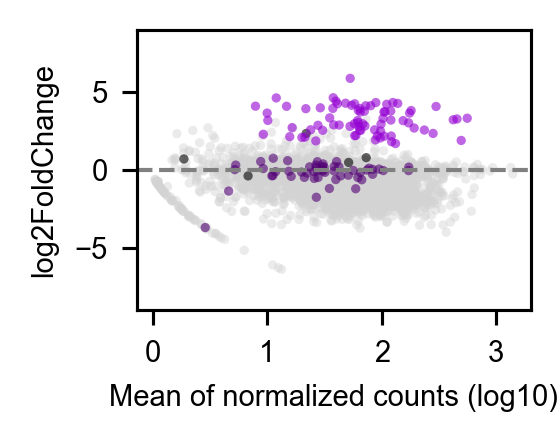

MEAN LFC of hits in pos side: 3.2085510520874485 => lfc_null for neg side: 2.117643694377716
######################
2.117643694377716
######################


Running Wald tests...
... done in 0.26 seconds.



Log2 fold change & Wald test p-value: condition ltd vs baseline
                          baseMean  log2FoldChange     lfcSE       stat  \
TCR                                                                       
2_18_B10_21_YPDKVFRSSV   41.148392        0.050732  0.513065  -4.028556   
2_16_H5_88_GLCTLVAML      7.831341       -1.120489  1.263481  -2.562867   
2_14_H15_182_LLWNGPMAV   52.603541       -0.120291  0.216470 -10.338330   
2_15_A2_1_LLWNGPMAV     122.498117       -2.245294  1.111764  -3.924340   
1_5_G2_73_YLQPRTFLL     101.537148       -0.481558  0.415582  -6.254370   
...                            ...             ...       ...        ...   
2_11_B10_21_NLVPMVATV     0.114058       -0.748580  4.827947  -0.593674   
2_11_G5_76_SPRWYFYYL      0.343199       -1.071520  4.819189  -0.661763   
2_11_C16_123_SPRWYFYYL    0.597896       -1.972084  4.623856  -0.884484   
1_7_B15_110_TTDPSFLGRY    1.481320        0.715011  3.208799  -0.437121   
1_7_D24_143_TTDPSFLGRY    0.117272  

Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.49 seconds.

Fitting dispersion trend curve...
... done in 0.06 seconds.

Fitting MAP dispersions...
... done in 0.52 seconds.

Fitting LFCs...
... done in 0.31 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Running Wald tests...


[0.65260725 0.66346238 0.57064904 0.40063087 0.54888853 0.61134493
 1.39805502 2.5908072  1.52272751 0.61403646 0.6070337  0.52945959
 0.93886212 0.8928313  1.55594283 1.11733844 0.33858376 1.09593328
 1.06590246 0.68764406 1.37348522 1.69616029 2.93391324 1.46862749]


... done in 0.26 seconds.



Log2 fold change & Wald test p-value: condition gil vs baseline
                          baseMean  log2FoldChange     lfcSE      stat  \
TCR                                                                      
2_18_B10_21_YPDKVFRSSV   41.148392       -1.333694  0.495593  0.000000   
2_16_H5_88_GLCTLVAML      7.831341       -1.562657  1.363447  0.000000   
2_14_H15_182_LLWNGPMAV   52.603541        0.105189  0.235018  0.447577   
2_15_A2_1_LLWNGPMAV     122.498117       -2.871398  1.109648  0.000000   
1_5_G2_73_YLQPRTFLL     101.537148        0.378496  0.416883  0.907917   
...                            ...             ...       ...       ...   
2_11_B10_21_NLVPMVATV     0.114058        0.515699  4.824112  0.106900   
2_11_G5_76_SPRWYFYYL      0.343199        0.210052  4.815790  0.043617   
2_11_C16_123_SPRWYFYYL    0.597896       -0.677047  4.756750  0.000000   
1_7_B15_110_TTDPSFLGRY    1.481320       -2.245331  3.699386  0.000000   
1_7_D24_143_TTDPSFLGRY    0.117272        0.5156

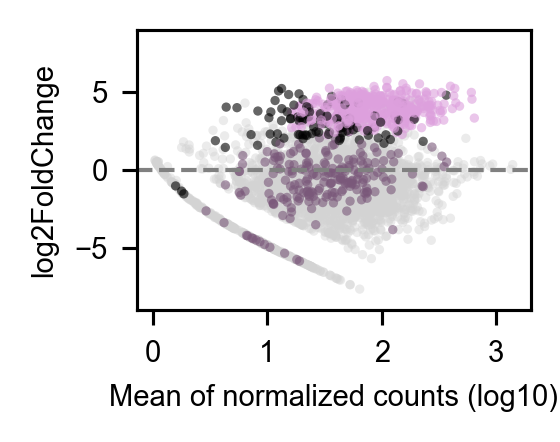

MEAN LFC of hits in pos side: 3.896759328724194 => lfc_null for neg side: 2.571861156957968
######################
2.571861156957968
######################


Running Wald tests...
... done in 0.32 seconds.



Log2 fold change & Wald test p-value: condition gil vs baseline
                          baseMean  log2FoldChange     lfcSE       stat  \
TCR                                                                       
2_18_B10_21_YPDKVFRSSV   41.148392       -1.333694  0.495593  -7.880569   
2_16_H5_88_GLCTLVAML      7.831341       -1.562657  1.363447  -3.032400   
2_14_H15_182_LLWNGPMAV   52.603541        0.105189  0.235018 -10.495658   
2_15_A2_1_LLWNGPMAV     122.498117       -2.871398  1.109648  -4.905393   
1_5_G2_73_YLQPRTFLL     101.537148        0.378496  0.416883  -5.261340   
...                            ...             ...       ...        ...   
2_11_B10_21_NLVPMVATV     0.114058        0.515699  4.824112  -0.426226   
2_11_G5_76_SPRWYFYYL      0.343199        0.210052  4.815790  -0.490430   
2_11_C16_123_SPRWYFYYL    0.597896       -0.677047  4.756750  -0.683010   
1_7_B15_110_TTDPSFLGRY    1.481320       -2.245331  3.699386  -1.302160   
1_7_D24_143_TTDPSFLGRY    0.117272  

Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.45 seconds.

Fitting dispersion trend curve...
... done in 0.06 seconds.

Fitting MAP dispersions...
... done in 0.52 seconds.

Fitting LFCs...
... done in 0.29 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Running Wald tests...


[0.65260725 0.66346238 0.57064904 0.40063087 0.54888853 0.61134493
 1.39805502 2.5908072  1.52272751 0.61403646 0.6070337  0.52945959
 0.93886212 0.8928313  1.55594283 1.11733844 0.33858376 1.09593328
 1.06590246 0.68764406 1.37348522 1.69616029 2.93391324 1.46862749]


... done in 0.24 seconds.



Log2 fold change & Wald test p-value: condition cin vs baseline
                          baseMean  log2FoldChange     lfcSE      stat  \
TCR                                                                      
2_18_B10_21_YPDKVFRSSV   41.148392       -0.391638  0.520546  0.000000   
2_16_H5_88_GLCTLVAML      7.831341        3.182107  0.716265  4.442637   
2_14_H15_182_LLWNGPMAV   52.603541       -0.295685  0.236341  0.000000   
2_15_A2_1_LLWNGPMAV     122.498117       -2.236668  1.118783  0.000000   
1_5_G2_73_YLQPRTFLL     101.537148        0.402842  0.416761  0.966601   
...                            ...             ...       ...       ...   
2_11_B10_21_NLVPMVATV     0.114058        0.177079  4.821114  0.036730   
2_11_G5_76_SPRWYFYYL      0.343199       -0.130963  4.812687  0.000000   
2_11_C16_123_SPRWYFYYL    0.597896        2.055756  4.090808  0.502530   
1_7_B15_110_TTDPSFLGRY    1.481320       -2.541764  3.641212  0.000000   
1_7_D24_143_TTDPSFLGRY    0.117272        0.1770

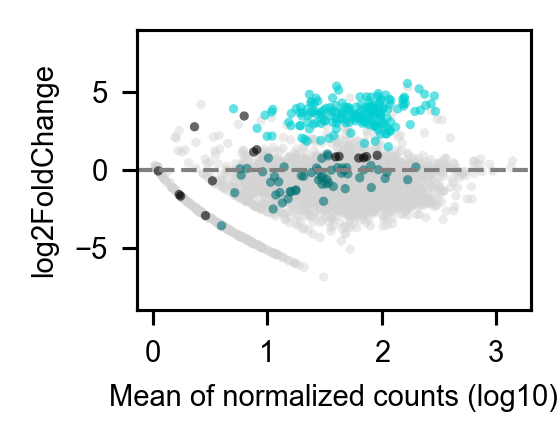

MEAN LFC of hits in pos side: 3.5583437803733187 => lfc_null for neg side: 2.3485068950463903
######################
2.3485068950463903
######################


Running Wald tests...


Log2 fold change & Wald test p-value: condition cin vs baseline
                          baseMean  log2FoldChange     lfcSE       stat  \
TCR                                                                       
2_18_B10_21_YPDKVFRSSV   41.148392       -0.391638  0.520546  -5.263988   
2_16_H5_88_GLCTLVAML      7.831341        3.182107  0.716265   0.000000   
2_14_H15_182_LLWNGPMAV   52.603541       -0.295685  0.236341 -11.188036   
2_15_A2_1_LLWNGPMAV     122.498117       -2.236668  1.118783  -4.098361   
1_5_G2_73_YLQPRTFLL     101.537148        0.402842  0.416761  -4.668539   
...                            ...             ...       ...        ...   
2_11_B10_21_NLVPMVATV     0.114058        0.177079  4.821114  -0.450400   
2_11_G5_76_SPRWYFYYL      0.343199       -0.130963  4.812687  -0.515195   
2_11_C16_123_SPRWYFYYL    0.597896        2.055756  4.090808  -0.071563   
1_7_B15_110_TTDPSFLGRY    1.481320       -2.541764  3.641212  -1.343034   
1_7_D24_143_TTDPSFLGRY    0.117272  

... done in 0.25 seconds.



In [ ]:
lfc_dict = {}
allele_collapsed_dict = {}
for plot_type in all_plot_types:

    figsize = (5/2.54, 4/2.54)
    # figsize = (14/2.54, 6.5/2.54)
    dotsize = 5
    fontsize_axes = 7
    background_alpha = 0.45
    color_alpha = 0.6
    edgecolor = 'none'

    print(f'Processing plot type: {plot_type}')
    for condition_name in condition_list_no_tetramer_ylq_glc:
        print(f'Processing condition: {condition_name}')
        if condition_name == 'spr':
            continue
        
        if condition_name != "GLCTLVAML_YLQPRTFLL" :
            stats_this_epi = stats_data_allv1[short_to_long_epi[condition_name]]
            intersection_ids = stats_this_epi['intersection_ids']
            ambiguous_ids = stats_this_epi['ambiguous_ids']
            pos_ids = stats_this_epi['pos_ids']
            neg_ids = stats_this_epi['neg_ids']

            
            meta_data = {name_long : name_long.split('_')[0] for name_long in counts_df.index}
            meta_data_df = pd.DataFrame(meta_data, index=['condition']).T.reset_index()
            meta_data_df.columns = ['run', 'condition']
            meta_data_df.index = meta_data_df['run']
            metadata = meta_data_df
            metadata['screen_day'] = [run_sets[run[0:3]] for run in counts_df.index]
            metadata = metadata.sort_index()
            # if condition column is not  condition_name, then replace with "baseline"
            metadata.loc[metadata['condition'] != condition_name, 'condition'] = 'baseline'
        else:
            continue
        
        ### DESEQ2 params
        SAVE = False
        min_n_reads = 0
        ### Data filtering
        samples_to_keep = ~metadata.condition.isna()
        counts_df = counts_df.loc[samples_to_keep]
        metadata = metadata.loc[samples_to_keep]
        # Filter out genes with less than min_n_reads
        genes_to_keep = counts_df.columns[counts_df.sum(axis=0) >= min_n_reads]
        counts_df = counts_df[genes_to_keep]
        # Run DESeq2
        inference = DefaultInference(n_cpus=8)

        control_genes = [gene if gene.split('_')[-1] not in all_epitopes else None for gene in counts_df.columns]
        # remove None
        control_genes = [gene for gene in control_genes if gene is not None]


        dds = DeseqDataSet(
            counts=counts_df,
            metadata=metadata,
            refit_cooks=False,
            inference=inference,
            # we dont use control genes and dont correct for screen_day or condition
            # design="~ screen_day + condition",  
            # control_genes=control_genes
        )
        dds.deseq2()
        print(dds.obsm["size_factors"])


        contrast = ["condition", condition_name, "baseline"]

        
        results_df = pd.DataFrame() # placeholder until the real df is defined (needed for pos/neg logic)
        for side in ['pos','neg']:
            condition_name_save = condition_name + '_' + side

            if side == 'pos':
                lfc_null = 0 
            else:

                hits_pos = results_df[results_df['color'] == name_color_dict[short_to_long_epi[condition_name]]]
                hits_pos = hits_pos.index
                mean_lfc = results_df[results_df.index.isin(hits_pos)]['log2FoldChange'].mean()
                lfc_dict[condition_name] = mean_lfc
                lfc_null = mean_lfc*0.66
                print('MEAN LFC of hits in pos side:', mean_lfc, '=> lfc_null for neg side:', lfc_null)
                print('######################')
                print(lfc_null)
                print('######################')

            alt_hypothesis = 'greater' if side == 'pos' else 'less'
            side_percentage = 5

            ds = DeseqStats(dds, 
                        contrast=contrast, 
                        cooks_filter=False,
                        independent_filter=False,
                        inference=inference,
                        )
            ds.summary(lfc_null=lfc_null, alt_hypothesis=alt_hypothesis)
            for shrink_no_shrink in [False,]: #True]:
                print(f'Running DESeq2 for condition: {condition_name}, shrink_no_shrink: {shrink_no_shrink}')
                if shrink_no_shrink:
                    ds.lfc_shrink(coeff=f'condition[T.{condition_name}]')
                else:
                    pass

                def get_significance_binary_color(padj, threshold, color):
                    if padj < threshold:
                        return color
                    return 'lightgrey'
                
                results_df = ds.results_df.copy()
                results_df['baseMean'] = results_df['baseMean'].apply(lambda x: np.log10(x + 1))
                results_df['color'] = 'lightgrey'
                
                results_df['epitope_split'] = results_df.index.str.split('_').str[-1]
                no_hit_df = results_df[~results_df['epitope_split'].isin(all_epitopes)]
                no_hit_df = no_hit_df.reset_index()
                no_hit_df['no_hit_ids'] = no_hit_df['TCR']

                not_top_10 = results_df[results_df.index.isin(no_hit_df['no_hit_ids'].values)]
                if side == 'neg':
                    red_line_y = np.sort(not_top_10['padj'])[int(len(not_top_10) * (100 - side_percentage) / 100)]
                else:
                    red_line_y = np.sort(not_top_10['padj'])[int(len(not_top_10) * (side_percentage / 100))]
                threshold_non_val = red_line_y
                threshold_dict[condition_name_save] = threshold_non_val
                padj_thresholds = [
                    100, 
                    threshold_non_val,
                    ]
                for threshold in padj_thresholds:
                    print(len(not_top_10), 'not top 10 epitopes')
                    print(f'Processing condition: {condition_name_save}, threshold: {threshold}')



                    condition_name_save = plot_type + '_' + condition_name + '_' + side

                    if plot_type == 'all-colored':
                        
                        if side == 'pos' and threshold != 100:
                            epitope_current = short_to_long_epi[condition_name]
                            results_df['color'] = 'lightgrey'
                            results_df.loc[results_df.index.str.contains(epitope_current), 'color'] = name_color_dict[epitope_current]

                           
                        else:
                            continue

                    if plot_type == 'pos-neg-ambig':
                        if side == 'pos' and threshold != 100:
                            results_df['color'] = 'lightgrey'
                            for index, row in results_df.iterrows():
                                if index in stats_data_allv1[short_to_long_epi[condition_name]]['pos_ids']:
                                    results_df.loc[index, 'color'] = name_color_dict[short_to_long_epi[condition_name]]
                                elif index in stats_data_allv1[short_to_long_epi[condition_name]]['neg_ids']:
                                    results_df.loc[index, 'color'] = name_color_dict_darker[short_to_long_epi[condition_name]]
                                elif index in stats_data_allv1[short_to_long_epi[condition_name]]['ambiguous_ids']:
                                    results_df.loc[index, 'color'] = 'black'
                                elif index in stats_data_allv1[short_to_long_epi[condition_name]]['intersection_ids']:
                                    results_df.loc[index, 'color'] = 'black'
                                else:
                                    results_df.loc[index, 'color'] = 'lightgrey'
                        else:
                            continue

                    if plot_type == 'pos-neg-only':
                    # pos and neg only (not intersection or ambiguous)
                        if threshold != 100:
                            results_df.loc[index, 'color'] = 'lightgrey'
                            for index, row in results_df.iterrows():
                                if side == 'pos':
                                    if index in stats_data_allv1[short_to_long_epi[condition_name]]['pos_ids']:
                                        results_df.loc[index, 'color'] = name_color_dict[short_to_long_epi[condition_name]]
                                elif side == 'neg':
                                    if index in stats_data_allv1[short_to_long_epi[condition_name]]['neg_ids']:
                                        results_df.loc[index, 'color'] = name_color_dict[short_to_long_epi[condition_name]]
                        else:
                            continue

                    # color the arrayed tested TCRs of pilot
                    if plot_type == 'arrayed-pilot':
                        if condition_name == 'glc' and side == 'pos' and threshold != 100:
                            condition_name_save = 'arrayed-pilot-glc-' + condition_name + '_' + side
                            results_df['color'] = 'lightgrey'
                            for index, row in results_df.iterrows():
                                if index in pilot_data_glc['name'].values:
                                    reactive_value = pilot_data_glc[pilot_data_glc['name'] == index]['Reactive'].values[0]
                                    if reactive_value == 1:
                                        results_df.loc[index, 'color'] = name_color_dict[short_to_long_epi[condition_name]]# '' #name_color_dict[short_to_long_epi[condition_name]]
                                    else:
                                        results_df.loc[index, 'color'] = 'black'

                        elif condition_name == 'ylq' and side == 'pos' and threshold != 100:
                            condition_name_save = 'arrayed-pilot-ylq-' + condition_name + '_' + side
                            results_df['color'] = 'lightgrey'
                            for index, row in results_df.iterrows():
                                if index in pilot_data_ylq['name'].values:
                                    reactive_value = pilot_data_ylq[pilot_data_ylq['name'] == index]['Reactive'].values[0]
                                    if reactive_value == 1:
                                        results_df.loc[index, 'color'] = name_color_dict[short_to_long_epi[condition_name]] # 'lightsalmon' #name_color_dict[short_to_long_epi[condition_name]]
                                    else:
                                        results_df.loc[index, 'color'] = 'black'
                        else:
                            continue
                
                
                    ## plot all grey NLV MA plot as example
                    if plot_type == 'all-grey-nlv':
                        if condition_name == 'nlv' and side == 'pos' and threshold != 100:
                            results_df['color'] = 'lightgrey'
                        else:
                            continue

                    if plot_type ==  'allele-collapsed':
                        if side == 'pos' and threshold != 100: 
                            results_df['color'] = 'lightgrey'
                            vdj_genes = ['TRAV', 'TRBV']
                            vdj_genes_different = {}
                            for vdj in vdj_genes:
                                same_vdj = ref_df_subset[vdj + '_IMGT'] == ref_df_subset[vdj +'_IMGT_allele_collapsed']
                                names = ref_df_subset[~same_vdj]['name']
                                names = names[names.str.contains(short_to_long_epi[condition_name])]

                                vdj_genes_different[vdj] = list(names)
                                print("allele collapsed results:")
                                print(vdj, len(vdj_genes_different[vdj]))

                            for index, row in results_df.iterrows():
                                if index in vdj_genes_different['TRAV'] or index in vdj_genes_different['TRBV']:
                                    results_df.loc[index, 'color'] = 'dimgrey'  
                                else:
                                    results_df.loc[index, 'color'] = 'lightgrey'
                        else:
                            continue
                    if plot_type == 'tetramer_only_hits':
                        tetramer_only = ["1_4_G17_172_YLQPRTFLL", "1_6_G14_169_YLQPRTFLL", "1_6_A24_107_YLQPRTFLL"]
                        if side == 'pos' and threshold != 100:
                            for index, row in results_df.iterrows():
                                if "YLQPRTFLL" in index:
                                        results_df.loc[index, 'color'] = name_color_dict[short_to_long_epi[condition_name]]
                                if index in tetramer_only:
                                    results_df.loc[index, 'color'] = 'black'
                        else:
                            continue

                    print(results_df[results_df['color'] == 'purple'].index.tolist())
                    if threshold < 1:
                        significant_hits = results_df['color'] != 'lightgrey'
                        sig_hits_dict_single_comp[condition_name_save] = results_df.loc[significant_hits].copy()

                    if threshold == 100 and 'pos' in condition_name_save:
                        pass
                    else:
                        if threshold == 100:
                            save_name_stats = condition_name + '_all'
                        else:
                            save_name_stats = condition_name_save

                        if 'tetramer' not in condition_name_save:
                            set_stats[save_name_stats] = {
                                'red_line_y': red_line_y,
                                'threshold_non_val': threshold_non_val,
                                'condition_name': condition_name,
                                'side': side,
                                'lfc': lfc_dict.get(condition_name, 0),
                                'lfc_066': lfc_dict.get(condition_name, 0) * 0.66,
                                'color': name_color_dict.get(short_to_long_epi[condition_name], 'lightgrey'),
                                'count' : results_df['color'].value_counts().get(name_color_dict.get(short_to_long_epi[condition_name], 'lightgrey'), 0),
                                # all of the name_color_dict.get(short_to_long_epi[condition_name]; get the ids
                                'ids': results_df[results_df['color'] == name_color_dict.get(short_to_long_epi[condition_name], 'lightgrey')].index.tolist(),
                                'any_above_thresh': results_df[results_df['padj'] < threshold].index.tolist(),
                                'hits_annotated_above_thresh': results_df[results_df.index.str.contains(short_to_long_epi[condition_name]) & (results_df['padj'] < threshold)].index.tolist(),
                                'hits_not_annotated_above_thresh': results_df[~results_df.index.str.contains(short_to_long_epi[condition_name]) & (results_df['padj'] < threshold)].index.tolist(),
                                'full_df': results_df.copy(),
                            }
                        
                        # if 'pos' in condition_name_save and threshold != 100:
                        #     results_df.to_csv(f'saved_dfs/results_df_{condition_name_save}_{threshold}.csv')

                    print(results_df['color'].value_counts())
                    print(short_to_long_epi[condition_name], condition_name)


                    #############
                    if 'pos' in condition_name_save:
                        sig_hits_dict_single_comp_dfs[condition_name] = results_df.copy()
                    
                    plt.figure(figsize=(figsize[0], figsize[1]))

                    color_list = results_df['color'].unique().tolist()
                    grey_mask = results_df['color'] == 'lightgrey'
                    grey_df = results_df[grey_mask].sample(frac=1, random_state=None)
                    plt.scatter(grey_df['baseMean'], grey_df['log2FoldChange'],
                                color='lightgrey', alpha=background_alpha,
                                s=dotsize, edgecolor=edgecolor)
                    other_df = results_df[~grey_mask].sample(frac=1, random_state=None)

                    for _, row in other_df.iterrows():
                        color = row['color']

                        if plot_type == 'arrayed-pilot' and color != 'black':
                            alpha = 1.0
                            dotsize_curr = dotsize
                            edgecolor_curr = edgecolor
                        elif plot_type == 'tetramer_only_hits' and color == 'black':
                            alpha = 1.0
                            dotsize_curr = 10
                            edgecolor_curr = edgecolor
                        elif plot_type == 'pos-neg-ambig':
                            alpha = color_alpha
                            dotsize_curr = dotsize
                            edgecolor_curr = edgecolor
                        else:
                            alpha = color_alpha
                            dotsize_curr = dotsize
                            edgecolor_curr = edgecolor

                        plt.scatter(row['baseMean'], row['log2FoldChange'],
                                    color=color, alpha=alpha,
                                    s=dotsize_curr, edgecolor=edgecolor_curr)
                    plt.ylim(-9, 9)
                    plt.xlabel('Mean of normalized counts (log10)', fontsize=fontsize_axes)
                    plt.ylabel('log2FoldChange', fontsize=fontsize_axes)

                    plt.axhline(0, color='grey', linestyle='--', linewidth=1)

                    plt.title(f'MA Plot - {condition_name_save} - {threshold}', fontsize=fontsize_axes)
        
                  
                    if SAVE_DROPBOX:
                        for color in color_list:
                            count_pos = 0
                            if color == name_color_dict[short_to_long_epi[condition_name]]:
                                count_pos = results_df[results_df['color'] == color].shape[0]
                        # remove title
                        plt.title('')
                        plt.savefig(out_path_dropbox + f'{condition_name_save}_MA_{threshold:.2f}_all{len(results_df)}_c{count_pos}.pdf', bbox_inches='tight', dpi=300)
                    elif SAVE:
                        legend_labels = []
                        for color in color_list:
                            count = results_df[results_df['color'] == color].shape[0]
                            if color in color_name_dict:
                                label = f"{color_name_dict[color]} ({count})"
                            else:
                                label = f"Other ({count})"
                            legend_labels.append(label)
                        # put it outside the plot on the right side
                        # plt.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=fontsize_axes, title='Significance', title_fontsize=fontsize_axes, frameon=False)
                        # plt.tight_layout()
                        # plt.savefig(f'saved_plots_all-v-1/{condition_name_save}_MA_{threshold:.2f}.pdf', 
                        #             # bbox_inches='tight',
                        #             dpi=300)
                            
                    plt.show()
                    plt.close()    


### calculate % validating with and without allele collapsed

In [139]:
vdj_genes = ['TRAV', 'TRBV']
vdj_genes_different = {}
before_v_after_ratios = {}
for condition_name in condition_list_no_tetramer_ylq_glc:
    print(f'Processing condition: {condition_name}' )
    if condition_name == 'GLCTLVAML_YLQPRTFLL' :
        continue

    pos_ids = stats_data_allv1[short_to_long_epi[condition_name]]['pos_ids']
    neg_ids = stats_data_allv1[short_to_long_epi[condition_name]]['neg_ids']
    pos_ids_before = pos_ids.copy()
    neg_ids_before = neg_ids.copy()

    ratio_before = round(100/ (len(pos_ids) + (len(neg_ids))) * len(pos_ids), 2)
    print('Ratio before allele collapsing:', ratio_before)

    for vdj in vdj_genes:
        same_vdj = ref_df_subset[vdj + '_IMGT'] == ref_df_subset[vdj +'_IMGT_allele_collapsed']
        names = ref_df_subset[~same_vdj]['name']
        names = names[names.str.contains(short_to_long_epi[condition_name])]

        vdj_genes_different[vdj] = list(names)
        print("allele collapsed results:")
        print(vdj, len(vdj_genes_different[vdj]))
        # remove from pos_ids and neg_ids
        pos_ids = [tid for tid in pos_ids if tid not in vdj_genes_different[vdj]]
        neg_ids = [tid for tid in neg_ids if tid not in vdj_genes_different[vdj]]
    ratio_after = round(100/ (len(pos_ids) + (len(neg_ids))) * len(pos_ids), 2)
    print('Ratio after allele collapsing:', ratio_after)
    no_difference = (len(pos_ids_before) == len(pos_ids)) and (len(neg_ids_before) == len(neg_ids))
    before_v_after_ratios[condition_name] = (ratio_before, ratio_after, no_difference)
    print()

Processing condition: glc
Ratio before allele collapsing: 65.09
allele collapsed results:
TRAV 5
allele collapsed results:
TRBV 41
Ratio after allele collapsing: 67.42

Processing condition: nlv
Ratio before allele collapsing: 28.26
allele collapsed results:
TRAV 9
allele collapsed results:
TRBV 16
Ratio after allele collapsing: 26.25

Processing condition: ylq
Ratio before allele collapsing: 40.62
allele collapsed results:
TRAV 0
allele collapsed results:
TRBV 0
Ratio after allele collapsing: 40.62

Processing condition: llw
Ratio before allele collapsing: 75.35
allele collapsed results:
TRAV 0
allele collapsed results:
TRBV 0
Ratio after allele collapsing: 75.35

Processing condition: ttd
Ratio before allele collapsing: 49.42
allele collapsed results:
TRAV 0
allele collapsed results:
TRBV 0
Ratio after allele collapsing: 49.42

Processing condition: ltd
Ratio before allele collapsing: 59.06
allele collapsed results:
TRAV 0
allele collapsed results:
TRBV 0
Ratio after allele collapsin

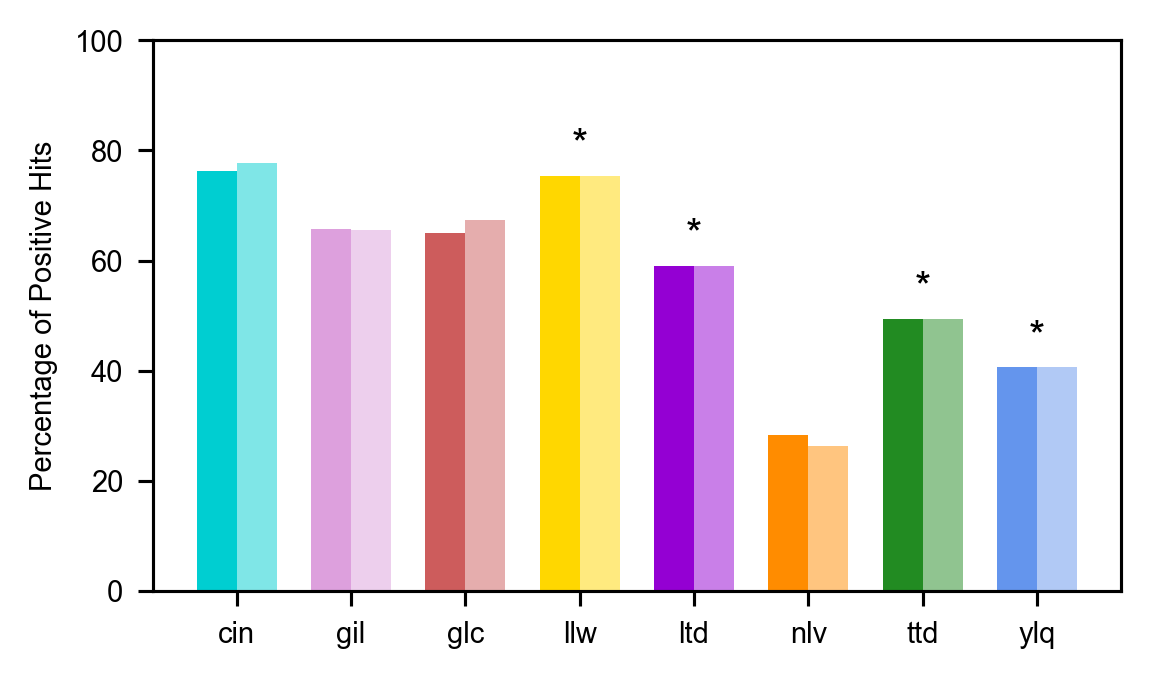

57.47625


In [ ]:
import matplotlib.pyplot as plt
conditions = list(before_v_after_ratios.keys())
sorted_conditions = sorted(conditions, key=lambda cond: short_to_long_epi.get(cond, ''))

mean_val_non_val = 0
x = np.arange(len(sorted_conditions)) 
width = 0.35  
fig, ax = plt.subplots(figsize=(10/2.54,6/2.54))
for i, cond in enumerate(sorted_conditions):
    before_ratios = before_v_after_ratios[cond][0]
    mean_val_non_val += before_ratios
    after_ratios = before_v_after_ratios[cond][1]
    no_difference = before_v_after_ratios[cond][2]
    ax.bar(x[i] - width/2, before_ratios, width, label='Before Allele Collapsing' if i == 0 else "", color=name_color_dict.get(short_to_long_epi[cond], 'lightblue'))
    ax.bar(x[i] + width/2, after_ratios, width, label='After Allele Collapsing' if i == 0 else "", color=name_color_dict.get(short_to_long_epi[cond], 'orange'), alpha=0.5) 
    if no_difference:
        ax.text(x[i], max(before_ratios, after_ratios) + 2, '*', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Percentage of Positive Hits', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(sorted_conditions, rotation=0, ha='center', fontsize=7)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(out_path_dropbox + 'allele_collapsing_effect_on_pos_hit_percentage.pdf', dpi=300)
plt.show()
plt.close()

print(mean_val_non_val / len(sorted_conditions))

### make the validating, non-validating, and ambiguous sets

In [ ]:
experiment_set_stats = {}

for experiment_name in set([name.split('_')[0] for name in set_stats.keys()]):

    # for pos and neg get the intersection of the ids
    pos_ids = set_stats.get(f"{experiment_name}_pos", {}).get('hits_annotated_above_thresh', [])
    neg_ids = set_stats.get(f"{experiment_name}_neg", {}).get('hits_annotated_above_thresh', [])
    all_ids = set_stats.get(f"{experiment_name}_all", {}).get('hits_annotated_above_thresh', [])
    other_hits = set_stats.get(f"{experiment_name}_pos", {}).get('hits_not_annotated_above_thresh', [])


    intersection_ids = set(pos_ids).intersection(set(neg_ids))
    # combine pos and neg unique ids and get the difference with all_ids
    unique_pos_neg_ids = set(pos_ids).union(set(neg_ids))
    ambiguous_ids = set(all_ids).difference(unique_pos_neg_ids)
    # remove intersection_ids from pos and neg ids
    pos_ids = [idx for idx in pos_ids if idx not in intersection_ids]
    neg_ids = [idx for idx in neg_ids if idx not in intersection_ids]
    # remove ambiguous_ids from pos and neg ids
    pos_ids = [idx for idx in pos_ids if idx not in ambiguous_ids]
    neg_ids = [idx for idx in neg_ids if idx not in ambiguous_ids]


    print(f"Experiment: {experiment_name}\n\t Intersection IDs: {len(intersection_ids)}, Ambiguous IDs: {len(ambiguous_ids)}, \n\t pos: {len(pos_ids)}, neg: {len(neg_ids)}, all: {len(all_ids)}")
    print(f"\t threshold pos: {set_stats.get(f'{experiment_name}_pos', {}).get('threshold_non_val', 'N/A')}, threshold neg: {set_stats.get(f'{experiment_name}_neg', {}).get('threshold_non_val', 'N/A')}")
    print(f"\t Other hits (not annotated for this epitope but above threshold): {len(other_hits)}")
    print('\t lfc and lfc * 066 neg:', set_stats[experiment_name+'_neg']['lfc'], set_stats[experiment_name+'_neg']['lfc_066'])

    
    
    
    # print valuecount of other hits
    other_hits_epi = [idx.split('_')[-1] for idx in other_hits]
    other_hits_counts = pd.Series(other_hits_epi).value_counts()
    # print(f"\t Other hits counts:\n{other_hits_counts}")


    experiment_set_stats[short_to_long_epi[experiment_name]] = {
        'intersection_ids': list(intersection_ids),
        'ambiguous_ids': list(ambiguous_ids),
        'pos_ids': list(pos_ids),
        'neg_ids': list(neg_ids),
        'all_ids': list(all_ids),
        'not_annotated_for_this_epitope_but_above_threshold': list(other_hits),
        'threshold_pos': set_stats.get(f"{experiment_name}_pos", {}).get('threshold_non_val', 'N/A'),
        'threshold_neg': set_stats.get(f"{experiment_name}_neg", {}).get('threshold_non_val', 'N/A'),
    }

print()
all_other_hits = []
for name, lists in experiment_set_stats.items():  
    for idx in lists['not_annotated_for_this_epitope_but_above_threshold']:
        all_other_hits.append(idx)

print(len(all_other_hits), 'all other hits')
print(len(set(all_other_hits)), 'unique other hits')

# get overlap with hits
all_hits = []
for name, lists in experiment_set_stats.items():
    all_hits.extend(lists['pos_ids'])

print(len(all_hits), 'all hits')
print(len(set(all_hits)), 'unique hits')
print(len(set(all_other_hits).intersection(set(all_hits))), 'overlap with hits')
print(len(set(all_other_hits).difference(set(all_hits))), 'other hits not in hits')


# # save the experiment_set_stats
# import json
# with open('saved_dfs/experiment_set_stats_all-v-1.json', 'w') as f:
#     json.dump(experiment_set_stats, f, indent=4)    

Experiment: gil
	 Intersection IDs: 4, Ambiguous IDs: 91, 
	 pos: 381, neg: 199, all: 675
	 threshold pos: 3.5610040809852533e-11, threshold neg: 0.0958961268828915
	 Other hits (not annotated for this epitope but above threshold): 87
	 lfc and lfc * 066 neg: 3.8775819599526433 2.5592040935687446
Experiment: nlv
	 Intersection IDs: 7, Ambiguous IDs: 42, 
	 pos: 91, neg: 231, all: 371
	 threshold pos: 0.23299834468519948, threshold neg: 0.01040302551976275
	 Other hits (not annotated for this epitope but above threshold): 86
	 lfc and lfc * 066 neg: 3.4064085623737927 2.2482296511667035
Experiment: ltd
	 Intersection IDs: 2, Ambiguous IDs: 3, 
	 pos: 75, neg: 52, all: 132
	 threshold pos: 0.3589197491838991, threshold neg: 0.027863743803339523
	 Other hits (not annotated for this epitope but above threshold): 85
	 lfc and lfc * 066 neg: 3.1415973977910205 2.0734542825420736
Experiment: ylq
	 Intersection IDs: 24, Ambiguous IDs: 17, 
	 pos: 158, neg: 231, all: 430
	 threshold pos: 0.1041